# Entendiendo FAS, FAC y FACP
### Notebook pedagógico — Series Temporales, Universidad Austral

---

## ¿Para qué sirven estas tres funciones?

Cuando tenés una serie temporal, no podés saber de entrada si es un AR, un MA, un ARMA o ruido blanco.  
La FAS, FAC y FACP son las **radiografías** de la serie: mirándolas, podés diagnosticar qué tipo de proceso la generó.

En este notebook vamos a **generar series sintéticas** de procesos conocidos y ver cómo se ven sus gráficos. Al final, cuando veas una FAC en el TP, vas a poder reconocer el patrón.

---

## Las tres funciones explicadas sin fórmulas

### FAS — Función de Autocovarianza
Pregunta: *¿Cuánto se mueve $Y_t$ junto con $Y_{t-k}$?*  
Mide si cuando la serie es alta hoy, tiende a ser alta también hace $k$ períodos.  
**No está normalizada** → los valores dependen de la escala de la serie.

### FAC — Función de Autocorrelación
Misma pregunta que la FAS, pero **normalizada entre -1 y 1**.  
Esto hace que sea comparable entre series con distintas escalas.  
Las **bandas punteadas** marcan el umbral de significancia estadística al 95%: rezagos fuera de las bandas tienen autocorrelación real (no por azar).

### FACP — Función de Autocorrelación Parcial
Pregunta más fina: *¿Cuánto se correlaciona $Y_t$ con $Y_{t-k}$ **descontando** el efecto de los rezagos intermedios?*  
Ejemplo: si el lunes influye en el miércoles solo porque el lunes influye en el martes y el martes en el miércoles, la FACP lo detecta y lo elimina. Solo muestra la **correlación directa**.

---

## La tabla que tenés que memorizar

| Proceso | FAC | FACP |
|:---:|:---:|:---:|
| **Ruido blanco** | Todo dentro de bandas | Todo dentro de bandas |
| **AR(p)** | Decae gradualmente | Se corta en el rezago $p$ |
| **MA(q)** | Se corta en el rezago $q$ | Decae gradualmente |
| **ARMA(p,q)** | Decae gradualmente | Decae gradualmente |
| **Random Walk** | Decae larguísimo (casi no baja) | Spike grande solo en lag 1 |

Al terminar este notebook, vas a entender visualmente cada fila de esta tabla.

---
## Antes de empezar: ¿qué es un AR, MA, ARMA y Ruido Blanco?

Todos estos modelos responden a la misma pregunta fundamental:

> **¿De qué depende el valor de la serie hoy?**

---

### Ruido Blanco — *"No depende de nada"*

$$Y_t = \varepsilon_t \qquad \varepsilon_t \sim N(0,\, \sigma^2)$$

El valor de hoy es azar puro. No tiene ninguna relación con el pasado.  
Saber lo que pasó ayer **no te ayuda en nada** a predecir hoy.

**Analogía:** tirar un dado — cada resultado es completamente independiente del anterior.

**Por qué importa:** los residuos de un buen modelo deben comportarse como ruido blanco. Si los residuos tienen estructura, el modelo dejó algo sin capturar.

---

### AR(p) — *"Depende de sus propios valores pasados"*

AR = **A**uto**r**egresivo. La serie se "explica a sí misma" mirando hacia atrás:

$$Y_t = \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \cdots + \phi_p Y_{t-p} + \varepsilon_t$$

- **$p$** = cuántos períodos hacia atrás mira (el "orden" del modelo)
- **$\phi_i$** = peso de cada rezago. Si $\phi_1 = 0.9$, el valor de hoy es casi igual al de ayer.
- Siempre hay un término de error $\varepsilon_t$ porque la predicción nunca es perfecta.

**Analogía:** la temperatura de hoy depende fuertemente de la de ayer y anteayer. Si ayer fue 30°C, hoy probablemente también sea cálido.

**Condición para que sea estacionario:** los coeficientes no pueden ser demasiado grandes. Para AR(1), basta con que $|\phi_1| < 1$. Si $\phi_1 = 1$ exactamente → Random Walk (no estacionario).

---

### MA(q) — *"Depende de errores (shocks) pasados"*

MA = **M**edia **M**óvil. La serie se explica por los errores aleatorios recientes, no por sus propios valores:

$$Y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q}$$

- **$q$** = cuántos períodos dura el efecto de un shock
- **Diferencia clave con el AR:** la memoria es *exacta y finita*. Pasados $q$ períodos, el efecto de un shock desaparece completamente. En el AR el efecto se disipa lentamente pero nunca llega a cero.

**Analogía:** el efecto de una noticia de mercado dura exactamente $q$ días y después desaparece del todo.

**Siempre es estacionario** (no importa el valor de $\theta$).

---

### ARMA(p,q) — *"Depende de ambos"*

Combina los dos modelos anteriores en uno solo:

$$Y_t = \underbrace{\phi_1 Y_{t-1} + \cdots + \phi_p Y_{t-p}}_{\text{componente AR}} + \underbrace{\varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}}_{\text{componente MA}}$$

- Es más **flexible**: captura estructuras que ni el AR ni el MA pueden por separado
- La desventaja es que es más difícil de identificar visualmente → se necesitan criterios AIC/BIC
- En la práctica, la mayoría de las series reales son bien representadas por ARMA con órdenes bajos ($p \leq 2,\, q \leq 2$)

---

### Random Walk — *"AR(1) con memoria infinita"*

$$Y_t = Y_{t-1} + \varepsilon_t$$

Es exactamente un AR(1) con $\phi_1 = 1$. Ese detalle lo cambia todo:

| | AR(1) con $\phi = 0.8$ | Random Walk ($\phi = 1$) |
|---|---|---|
| Efecto de un shock | Se disipa con el tiempo | Se acumula **para siempre** |
| Media | Constante | Deriva sin límite |
| Varianza | Constante | Crece indefinidamente |
| Estacionaria | ✅ Sí | ❌ No |

**Analogía:** imaginá que cada día das un paso aleatorio hacia adelante o hacia atrás. Después de 1000 días, podés estar muy lejos de donde empezaste. Los precios de acciones se mueven así.

---

> **Resumen en una oración:** AR mira sus propios valores pasados, MA mira sus propios errores pasados, ARMA mira ambos, ruido blanco no mira nada, random walk es AR con tanta memoria que se vuelve no estacionario.

In [3]:
!pip install statsmodels

zsh:1: command not found: pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)      # fijamos la semilla para reproducibilidad
N    = 400              # número de observaciones por serie
LAGS = 30               # cantidad de rezagos a graficar

plt.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8-whitegrid')
print('OK')

OK


In [5]:
# ─── Función auxiliar central ─────────────────────────────────────────────
# Esta función hace todo el trabajo visual para cualquier serie que le pases.

def graficar_serie_y_funciones(serie, titulo, color='steelblue', lags=LAGS):
    """
    Recibe una serie numpy/pandas y grafica:
      Fila 1: la serie temporal
      Fila 2: FAS | FAC | FACP
    """
    s = np.array(serie)
    T = len(s)
    mu = s.mean()

    # --- Cálculo manual de la FAS ---
    fas = [(1/T) * np.sum((s[k:] - mu) * (s[:T-k] - mu)) for k in range(lags+1)]

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))

    # ── Fila 1: serie temporal (ocupa las 3 columnas) ─────────────────────
    ax_serie = plt.subplot2grid((2, 3), (0, 0), colspan=3, fig=fig)
    ax_serie.plot(s, color=color, linewidth=0.9, alpha=0.85)
    ax_serie.axhline(mu, color='black', linestyle='--', linewidth=1, label=f'Media = {mu:.2f}')
    ax_serie.set_title(f'Serie temporal: {titulo}', fontweight='bold', fontsize=12)
    ax_serie.set_xlabel('Tiempo (t)')
    ax_serie.legend()

    # ── Fila 2, panel 1: FAS ──────────────────────────────────────────────
    ax_fas = plt.subplot2grid((2, 3), (1, 0), fig=fig)
    ax_fas.bar(range(lags+1), fas, color=color, alpha=0.7, width=0.6)
    ax_fas.axhline(0, color='black', linewidth=0.8)
    ax_fas.set_title('FAS — Autocovarianza')
    ax_fas.set_xlabel('Rezago k')
    ax_fas.set_ylabel('γ(k)')

    # ── Fila 2, panel 2: FAC ──────────────────────────────────────────────
    ax_fac = plt.subplot2grid((2, 3), (1, 1), fig=fig)
    plot_acf(s, lags=lags, ax=ax_fac, color=color, alpha=0.05)
    ax_fac.set_title('FAC — Autocorrelación')
    ax_fac.set_xlabel('Rezago k')

    # ── Fila 2, panel 3: FACP ─────────────────────────────────────────────
    ax_facp = plt.subplot2grid((2, 3), (1, 2), fig=fig)
    plot_pacf(s, lags=lags, ax=ax_facp, color=color, alpha=0.05, method='ywm')
    ax_facp.set_title('FACP — Autocorrelación Parcial')
    ax_facp.set_xlabel('Rezago k')

    plt.suptitle(titulo, fontsize=13, fontweight='bold', color=color, y=1.01)
    plt.tight_layout()
    plt.show()

---
## Proceso 1 — Ruido Blanco

### ¿Qué es?
El proceso más simple posible. Cada valor es un número aleatorio **completamente independiente** de todos los demás.

$$Y_t = \varepsilon_t \qquad \varepsilon_t \sim N(0, \sigma^2)$$

Características:
- Media = 0, varianza constante
- **Cero correlación** entre cualquier par de valores: saber $Y_t$ no te dice nada sobre $Y_{t+1}$
- Es **estacionario** (de hecho, es el proceso estacionario más simple)
- En la práctica, los **residuos** de un buen modelo deben comportarse como ruido blanco

### ¿Qué esperamos ver?
- **FAC y FACP:** todos los rezagos *dentro* de las bandas (no hay correlación con el pasado)

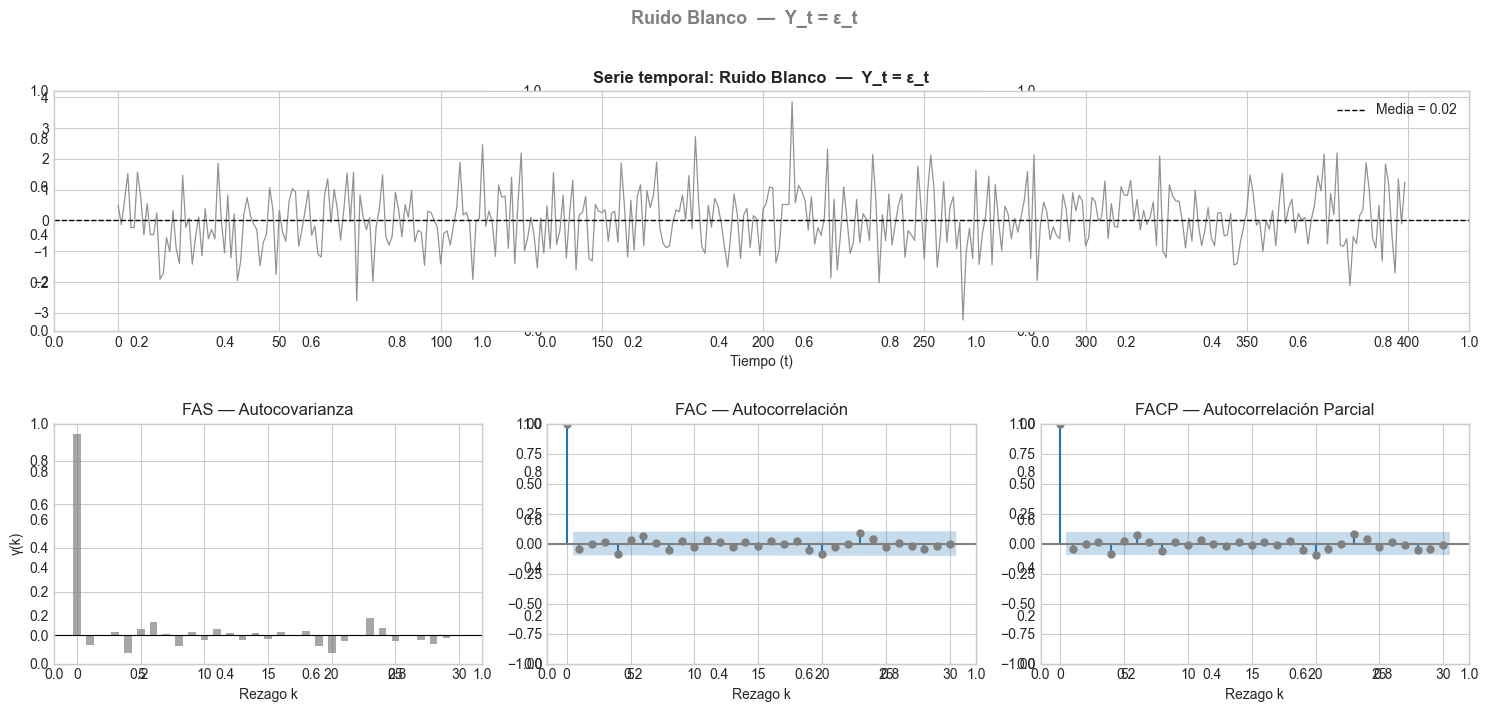

In [6]:
ruido_blanco = np.random.normal(0, 1, N)
graficar_serie_y_funciones(ruido_blanco, 'Ruido Blanco  —  Y_t = ε_t', color='gray')

### Qué vemos

- **Serie:** oscila aleatoriamente alrededor de 0, sin ningún patrón.
- **FAS:** cae inmediatamente a cero en los rezagos > 0.
- **FAC:** el rezago 0 siempre vale 1 (correlación de la serie consigo misma). Todos los demás están dentro de las bandas → **no hay autocorrelación**.
- **FACP:** ídem.

> Esto es el **punto de referencia**: cuando el modelo ajuste bien, sus residuos deben verse así.

---
## Proceso 2 — AR(1) con φ = 0.8 (memoria positiva fuerte)

### ¿Qué es?
Un proceso **Autoregresivo de orden 1**: cada valor depende del valor anterior más un error.

$$Y_t = 0.8 \cdot Y_{t-1} + \varepsilon_t$$

Interpretación: si hoy la serie está alta, mañana probablemente también lo esté (80% de persistencia).  
Con φ = 0.8 la memoria es **fuerte**: los shocks tardan en disiparse.

Es **estacionario** porque |φ| < 1 (condición necesaria para AR(1)).

### ¿Qué esperamos ver?
- **FAC:** decaimiento exponencial suave (los rezagos altos siguen siendo significativos, pero van bajando)
- **FACP:** spike significativo *solo* en el rezago 1, el resto dentro de las bandas → nos dice que el orden es p=1

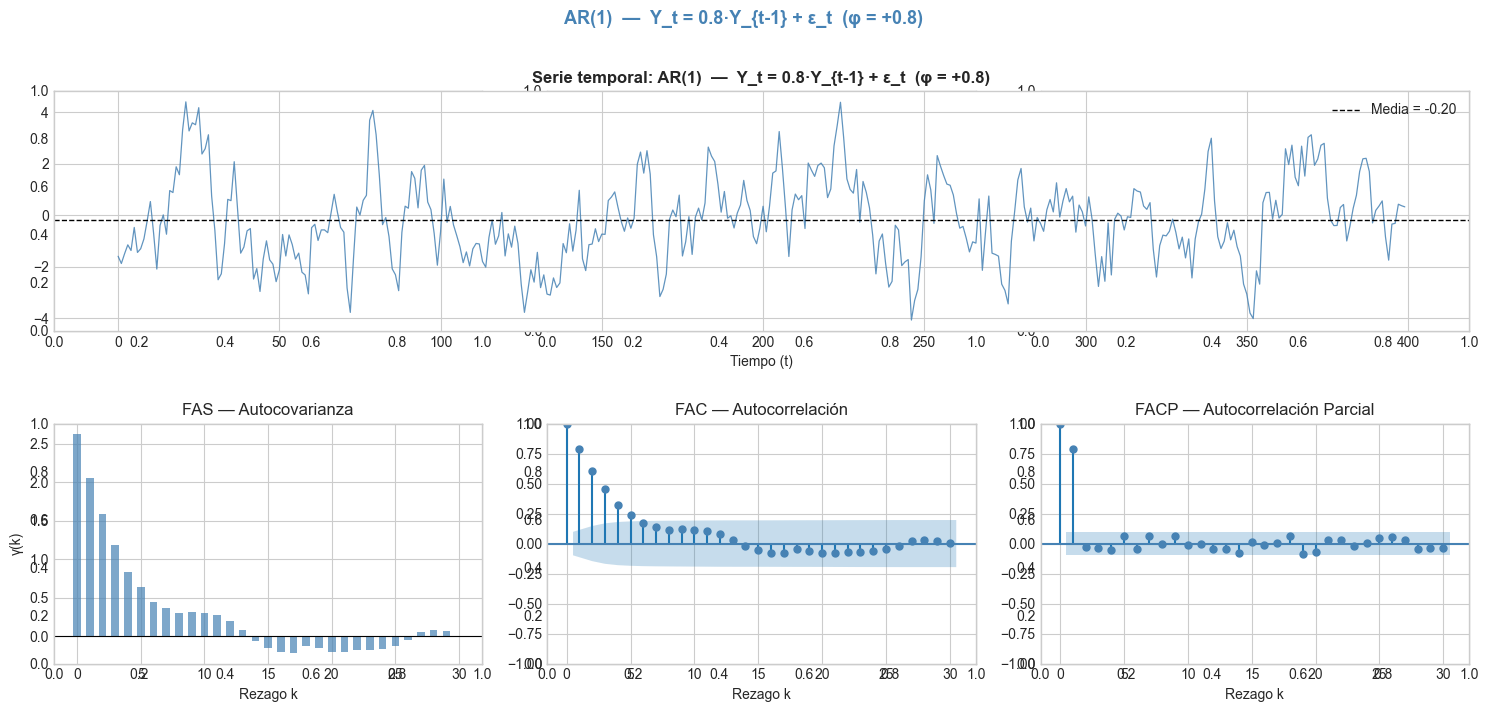

In [7]:
# En statsmodels: ar=[1, -φ], ma=[1]
ar1_pos = ArmaProcess(ar=[1, -0.8], ma=[1]).generate_sample(N)
graficar_serie_y_funciones(ar1_pos, 'AR(1)  —  Y_t = 0.8·Y_{t-1} + ε_t  (φ = +0.8)', color='steelblue')

### Qué vemos

- **Serie:** se mueve en "olas" suaves. Los valores cercanos en el tiempo son parecidos (la serie "recuerda" su pasado reciente).
- **FAC:** decae exponencialmente. El lag 1 es muy alto (~0.8), el lag 2 es ~0.64, el lag 3 ~0.51... La fórmula teórica es $\rho(k) = \phi^k = 0.8^k$. Muchos rezagos son significativos.
- **FACP:** solo el lag 1 es significativo, el resto dentro de las bandas.

> **Regla AR:** la FACP te dice el orden del AR. Un spike en lag 1 y corte → AR(1). Si hubiera spikes en lag 1 y 2 → AR(2).

---
## Proceso 3 — AR(1) con φ = −0.8 (memoria negativa)

### ¿Qué es?
$$Y_t = -0.8 \cdot Y_{t-1} + \varepsilon_t$$

Ahora el coeficiente es **negativo**: si hoy está alto, mañana tiende a estar bajo, y pasado mañana alto de nuevo.  
Genera un patrón de **zigzag** característico. También estacionario (|φ| < 1).

### ¿Qué esperamos ver?
- **FAC:** decaimiento alternando signos (+ − + − ...)
- **FACP:** spike negativo solo en el lag 1

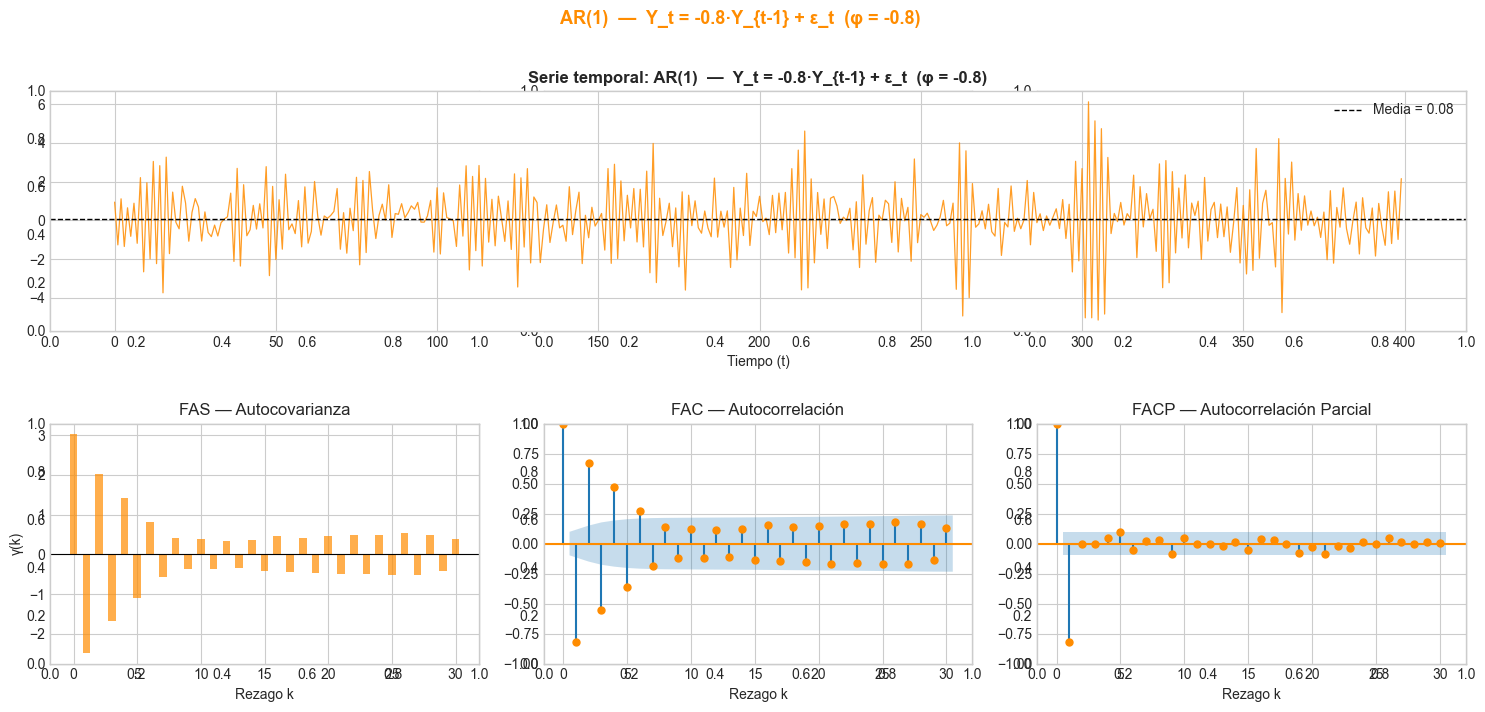

In [8]:
ar1_neg = ArmaProcess(ar=[1, 0.8], ma=[1]).generate_sample(N)
graficar_serie_y_funciones(ar1_neg, 'AR(1)  —  Y_t = -0.8·Y_{t-1} + ε_t  (φ = -0.8)', color='darkorange')

### Qué vemos

- **Serie:** zigzag pronunciado — sube, baja, sube, baja. Muy diferente al AR(1) con φ positivo.
- **FAC:** valores que **alternan entre positivo y negativo** y van disminuyendo en magnitud. El lag 1 es ~-0.8, lag 2 ~+0.64, lag 3 ~-0.51...
- **FACP:** solo el lag 1 es significativo (negativo), confirmando AR(1).

> **El signo del coeficiente cambia la forma de la FAC**, pero el patrón de la FACP (corte en p=1) es el mismo. Por eso la FACP es más útil para identificar el orden.

---
## Proceso 4 — AR(2)

### ¿Qué es?
$$Y_t = 0.6 \cdot Y_{t-1} + 0.3 \cdot Y_{t-2} + \varepsilon_t$$

Ahora el valor actual depende de los **dos períodos anteriores**. La memoria es más larga y el comportamiento más complejo.

### ¿Qué esperamos ver?
- **FAC:** decaimiento gradual (posiblemente con oscilaciones según los parámetros)
- **FACP:** spikes significativos en lag 1 **y** lag 2, luego corte → nos dice p=2

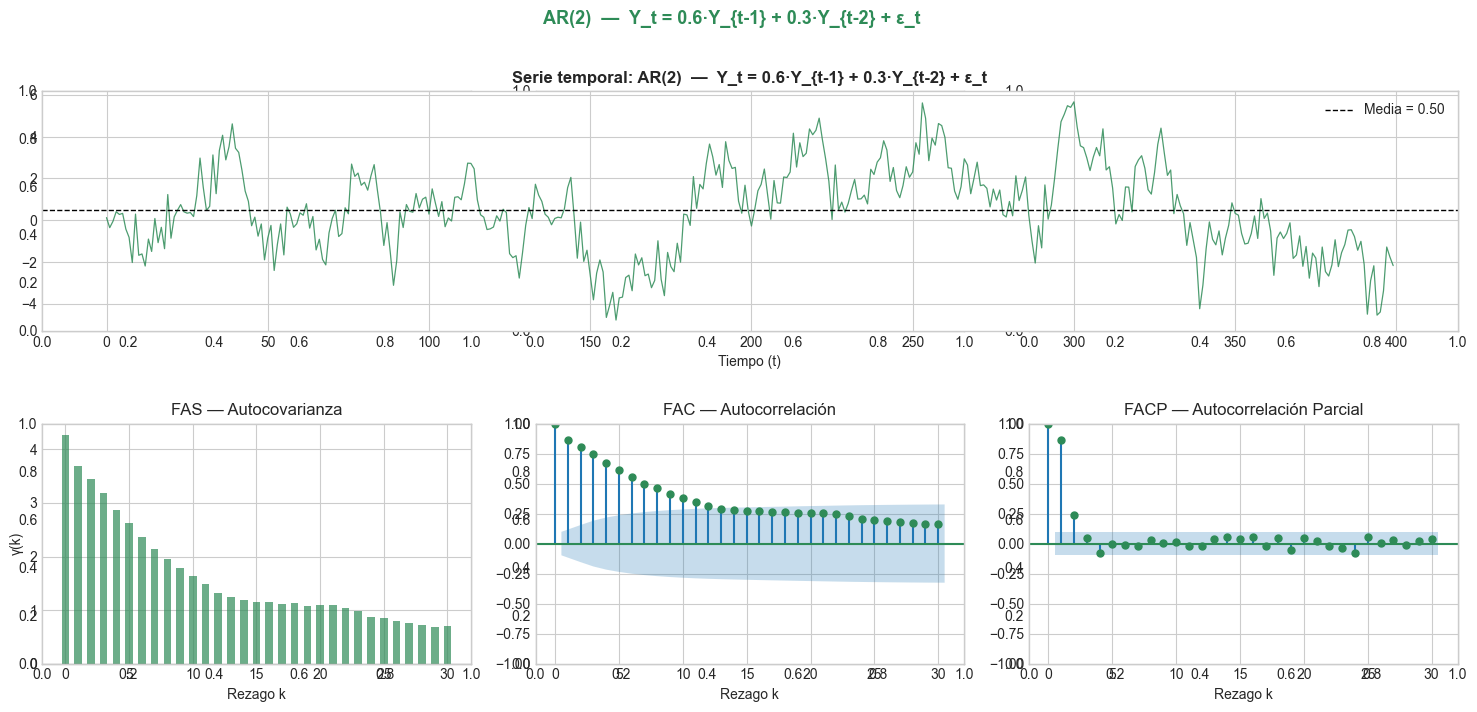

In [9]:
ar2 = ArmaProcess(ar=[1, -0.6, -0.3], ma=[1]).generate_sample(N)
graficar_serie_y_funciones(ar2, 'AR(2)  —  Y_t = 0.6·Y_{t-1} + 0.3·Y_{t-2} + ε_t', color='seagreen')

### Qué vemos

- **Serie:** movimientos más suaves y lentos que el AR(1), porque depende de dos rezagos.
- **FAC:** decaimiento gradual, similar al AR(1) pero potencialmente con oscilaciones.
- **FACP:** spikes significativos en los lags 1 y 2, y a partir del lag 3 cae dentro de las bandas → **corte en 2** → AR(2).

> **Regla:** la FACP "corta" en el orden del proceso AR. Si cortara en lag 5, diríamos AR(5).

---
## Proceso 5 — MA(1)

### ¿Qué es?
Un proceso de **Media Móvil de orden 1**: el valor actual depende del error de hoy y del error de ayer (no del valor de ayer).

$$Y_t = \varepsilon_t + 0.8 \cdot \varepsilon_{t-1}$$

La diferencia con el AR: aquí la "memoria" es corta y **exactamente** de 1 período. Pasado ese período, no hay ningún efecto.

### ¿Qué esperamos ver?
- **FAC:** spike significativo **solo** en el lag 1, el resto dentro de las bandas → corte en q=1
- **FACP:** decaimiento gradual (la correlación parcial va disminuyendo lentamente)

> Notá que **las reglas de FAC y FACP se invierten** respecto al AR: ahora es la FAC la que corta, y la FACP la que decae.

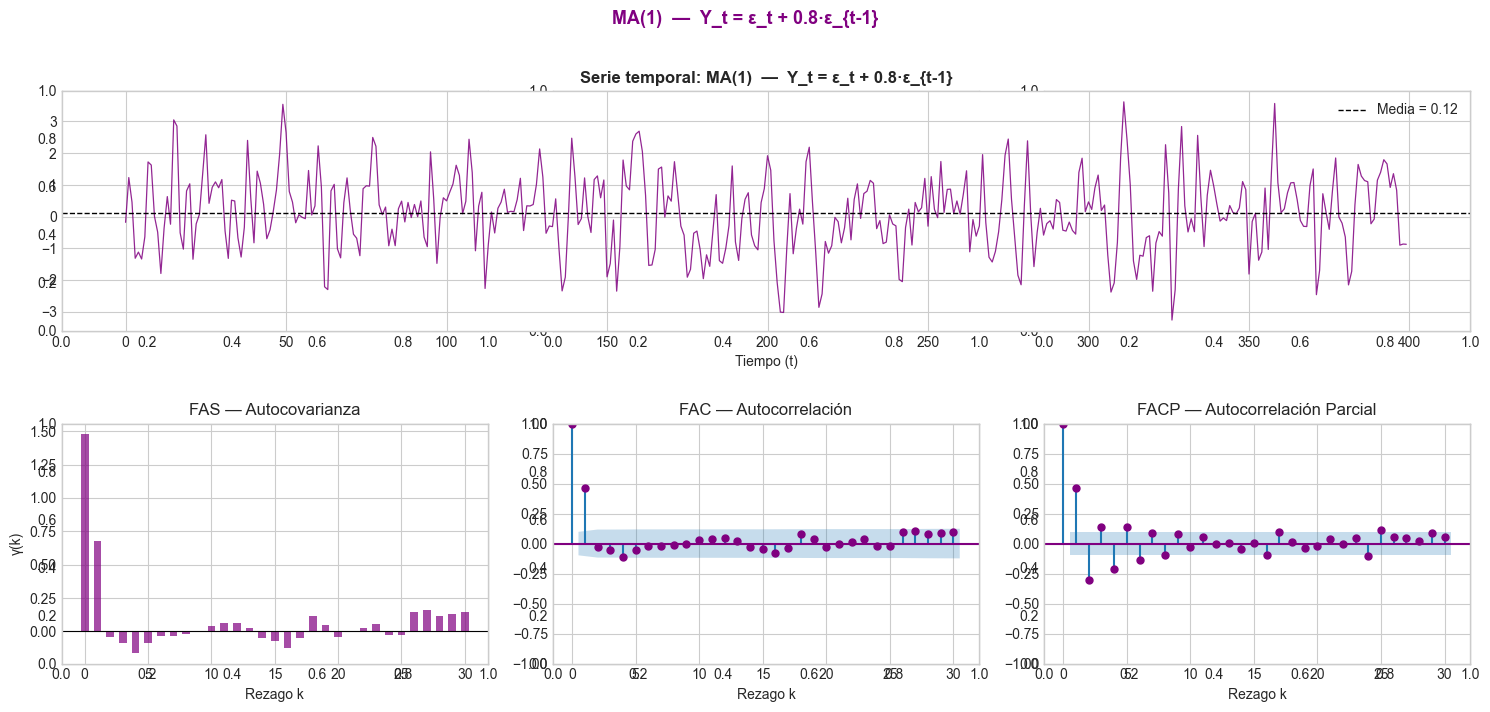

In [10]:
ma1 = ArmaProcess(ar=[1], ma=[1, 0.8]).generate_sample(N)
graficar_serie_y_funciones(ma1, 'MA(1)  —  Y_t = ε_t + 0.8·ε_{t-1}', color='purple')

### Qué vemos

- **Serie:** oscilaciones rápidas, sin la "inercia" del AR. La serie cambia de dirección más frecuentemente.
- **FAC:** el lag 1 es significativo (~0.44 teórico), los demás **dentro de las bandas** → corte brusco en q=1. Este patrón es inconfundible.
- **FACP:** decaimiento alternado, varios rezagos salen de las bandas.

> Comparalo con el AR(1): en el AR(1) era la FACP la que cortaba en 1; en el MA(1) es la FAC la que corta en 1. **Son simétricas en el diagnóstico.**

---
## Proceso 6 — MA(2)

### ¿Qué es?
$$Y_t = \varepsilon_t + 0.7 \cdot \varepsilon_{t-1} + 0.4 \cdot \varepsilon_{t-2}$$

La memoria ahora dura exactamente 2 períodos.

### ¿Qué esperamos ver?
- **FAC:** corte en lag 2 (lags 1 y 2 significativos, luego nada)
- **FACP:** decaimiento gradual

In [ ]:
ma2 = ArmaProcess(ar=[1], ma=[1, 0.7, 0.4]).generate_sample(N)
graficar_serie_y_funciones(ma2, 'MA(2)  —  Y_t = ε_t + 0.7·ε_{t-1} + 0.4·ε_{t-2}', color='teal')

### Qué vemos

- **FAC:** los lags 1 y 2 son significativos, a partir del lag 3 entra en las bandas → corte en q=2.
- **FACP:** decaimiento, varios rezagos significativos pero sin un corte claro.

> La diferencia con el MA(1) es clara: ahora son **dos** rezagos significativos en la FAC antes del corte.

---
## Proceso 7 — ARMA(1,1)

### ¿Qué es?
Combina un componente AR y uno MA:

$$Y_t = 0.7 \cdot Y_{t-1} + \varepsilon_t + 0.5 \cdot \varepsilon_{t-1}$$

### ¿Qué esperamos ver?
- **FAC:** decaimiento gradual (sin corte brusco)
- **FACP:** decaimiento gradual (sin corte brusco)

Este es el caso más difícil de identificar: ambas funciones decaen y no se puede determinar $p$ ni $q$ visualmente con precisión. Ahí es donde entran los **criterios de información** (AIC, BIC) para seleccionar el mejor modelo.

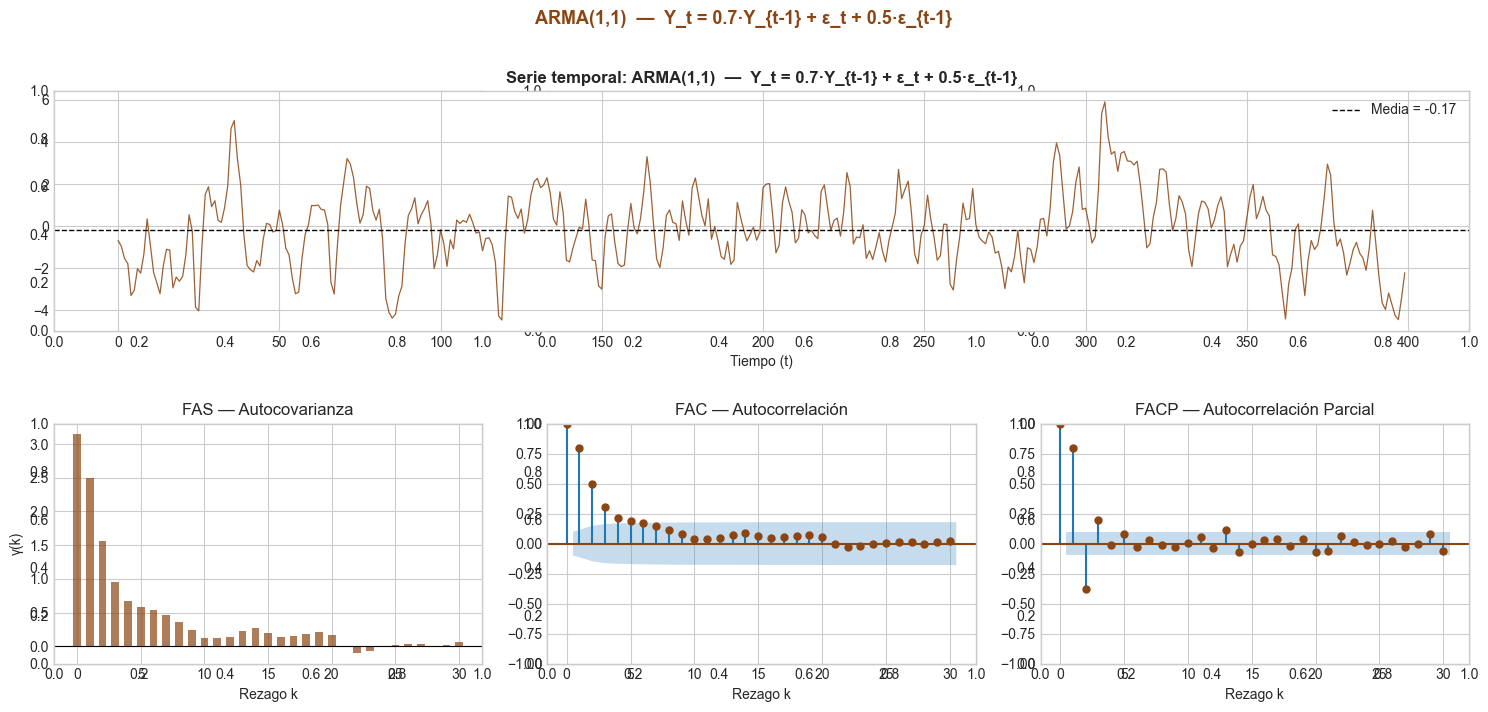

In [11]:
arma11 = ArmaProcess(ar=[1, -0.7], ma=[1, 0.5]).generate_sample(N)
graficar_serie_y_funciones(arma11, 'ARMA(1,1)  —  Y_t = 0.7·Y_{t-1} + ε_t + 0.5·ε_{t-1}', color='saddlebrown')

### Qué vemos

- **FAC:** decae gradualmente, sin un corte claro.
- **FACP:** también decae gradualmente, sin un corte claro.

> Cuando **ninguna de las dos corta**, el diagnóstico es ARMA. No podés saber el orden exacto solo mirando: necesitás ajustar varios modelos y comparar AIC/BIC.

---
## Proceso 8 — Random Walk (Caminata Aleatoria)

### ¿Qué es?
El proceso **NO estacionario** más importante en finanzas:

$$Y_t = Y_{t-1} + \varepsilon_t$$

Es un AR(1) con φ = 1 exactamente. La diferencia con el AR(1) estacionario (φ = 0.8):  
- En el AR(1) con φ < 1, los shocks se disipan con el tiempo  
- En el random walk, los shocks **se acumulan para siempre** → la serie "se aleja" indefinidamente de su punto de partida

Los precios de acciones, índices y criptomonedas se comportan así.

### ¿Qué esperamos ver?
- **FAC:** decaimiento **extremadamente lento** (casi no baja de 1 en los primeros rezagos)
- **FACP:** spike grande en lag 1, el resto dentro de las bandas

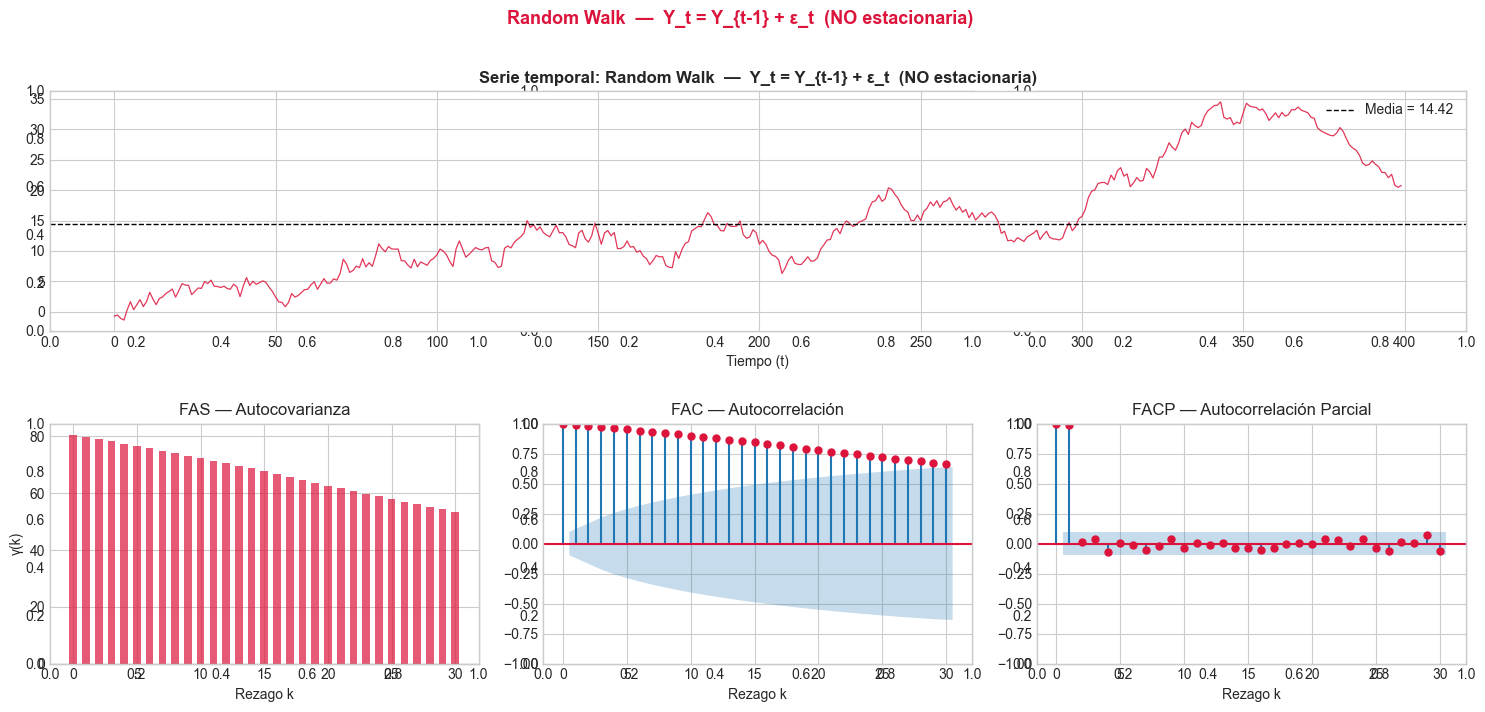

In [12]:
random_walk = np.cumsum(np.random.normal(0, 1, N))   # suma acumulada de ruido blanco
graficar_serie_y_funciones(random_walk, 'Random Walk  —  Y_t = Y_{t-1} + ε_t  (NO estacionaria)', color='crimson')

### Qué vemos

- **Serie:** se aleja de cero y no vuelve. No tiene un nivel "central" al que regresar.
- **FAC:** valores cercanos a 1 durante decenas de rezagos, casi sin caer. **Este es el patrón diagnóstico de raíz unitaria.** Nunca verías esto en una serie estacionaria.
- **FACP:** spike enorme en lag 1 (φ ≈ 1), el resto dentro de las bandas.

> **¿Qué hacemos con esto?** Lo diferenciamos: $\Delta Y_t = Y_t - Y_{t-1} = \varepsilon_t$ → obtenemos ruido blanco. Por eso el S&P 500 diferenciado se ve como ruido blanco.

---
## Comparación final: los 8 procesos uno al lado del otro

El siguiente gráfico resume solo las **FAC de todos los procesos** para que quede clara la diferencia de un vistazo.

In [13]:
procesos = [
    (ruido_blanco, 'Ruido Blanco',         'gray'),
    (ar1_pos,      'AR(1) φ=+0.8',         'steelblue'),
    (ar1_neg,      'AR(1) φ=-0.8',         'darkorange'),
    (ar2,          'AR(2)',                 'seagreen'),
    (ma1,          'MA(1)',                 'purple'),
    (ma2,          'MA(2)',                 'teal'),
    (arma11,       'ARMA(1,1)',             'saddlebrown'),
    (random_walk,  'Random Walk',           'crimson'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (serie, nombre, color) in zip(axes, procesos):
    plot_acf(serie, lags=20, ax=ax, color=color, alpha=0.05)
    ax.set_title(nombre, fontweight='bold', fontsize=10, color=color)
    ax.set_xlabel('Rezago k', fontsize=8)
    ax.set_ylim(-1.2, 1.2)

plt.suptitle('FAC comparativa — los 8 procesos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'ma2' is not defined

In [ ]:
# Lo mismo pero con la FACP
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (serie, nombre, color) in zip(axes, procesos):
    plot_pacf(serie, lags=20, ax=ax, color=color, alpha=0.05, method='ywm')
    ax.set_title(nombre, fontweight='bold', fontsize=10, color=color)
    ax.set_xlabel('Rezago k', fontsize=8)
    ax.set_ylim(-1.2, 1.2)

plt.suptitle('FACP comparativa — los 8 procesos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Resumen: el diagnóstico en la práctica

Cuando en el TP mirés la FAC y FACP de una serie, seguí este flujo:

```
¿La FAC decae lentísimo (sigue alta en lag 15, 20, 25...)?
        │
        ├─ SÍ → Raíz unitaria → diferenciá la serie, luego volvé a empezar
        │
        └─ NO → Serie estacionaria → identificá el proceso:
                    │
                    ├─ FAC corta en q, FACP decae  →  MA(q)
                    ├─ FACP corta en p, FAC decae  →  AR(p)
                    └─ Ambas decaen gradualmente   →  ARMA(p,q) → usá AIC/BIC
```

### Conexión con el TP

| Serie del TP | Comportamiento en niveles | Acción |
|---|---|---|
| S&P 500 | FAC = Random Walk (lentísimo) | Diferenciar ($d=1$), luego FAC ≈ ruido blanco |
| VIX | FAC decae como AR estacionario | Modelar directamente ($d=0$), FACP sugiere AR(1) o AR(2) |